In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.columns = [k.lower() for k in df.columns]

In [4]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
for col in ['pclass', 'sibsp', 'parch', 'embarked']:
    print(f"\n{col}:\n", df[col].value_counts(normalize=True).round(3))


pclass:
 pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64

sibsp:
 sibsp
0    0.682
1    0.235
2    0.031
4    0.020
3    0.018
8    0.008
5    0.006
Name: proportion, dtype: float64

parch:
 parch
0    0.761
1    0.132
2    0.090
5    0.006
3    0.006
4    0.004
6    0.001
Name: proportion, dtype: float64

embarked:
 embarked
S    0.724
C    0.189
Q    0.087
Name: proportion, dtype: float64


In [6]:
pd.crosstab(df['embarked'], df['pclass'], normalize='index').round(3)

pclass,1,2,3
embarked,,,
C,0.506,0.101,0.393
Q,0.026,0.039,0.935
S,0.197,0.255,0.548


In [7]:
df[df.parch==0].pclass.value_counts(True)

pclass
3    0.561947
1    0.240413
2    0.197640
Name: proportion, dtype: float64

In [8]:
pd.crosstab(df['embarked'],df['sex'],  normalize='index').round(3)

sex,female,male
embarked,,
C,0.435,0.565
Q,0.468,0.532
S,0.315,0.685


In [9]:
from scipy.stats import chi2_contingency

for col in ['sibsp', 'parch']:
    ct = pd.crosstab(df['embarked'] == 'Q', df[col])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.3f}, p={p:.4f}")

sibsp: chi2=10.896, p=0.0916
parch: chi2=11.214, p=0.0820


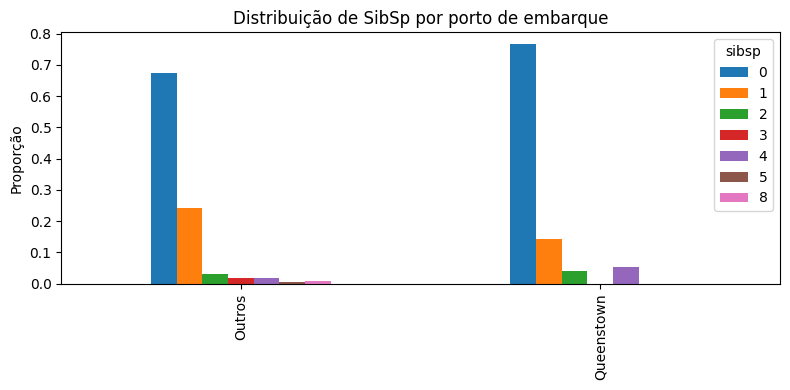

In [10]:
import matplotlib.pyplot as plt

ct = pd.crosstab(df['embarked'] == 'Q', df['sibsp'], normalize='index')
ct.index = ['Outros', 'Queenstown']
ct.plot(kind='bar', figsize=(8, 4))
plt.ylabel('Proporção')
plt.title('Distribuição de SibSp por porto de embarque')
plt.legend(title='sibsp')
plt.tight_layout()
plt.show()

In [11]:
mask = (df['embarked'] == 'Q') & (df['sex'] == 'female')
df[mask]['sibsp'].apply(lambda x: x >= 1).value_counts(normalize=True).round(3)

sibsp
False    0.806
True     0.194
Name: proportion, dtype: float64

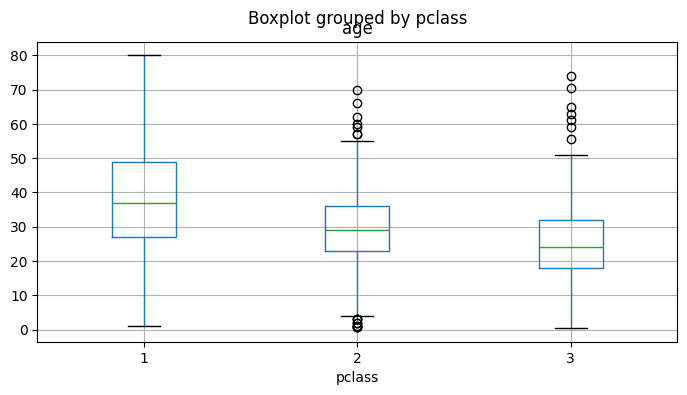

In [12]:
df.boxplot(column='age', by='pclass', figsize=(8, 4))
plt.show()

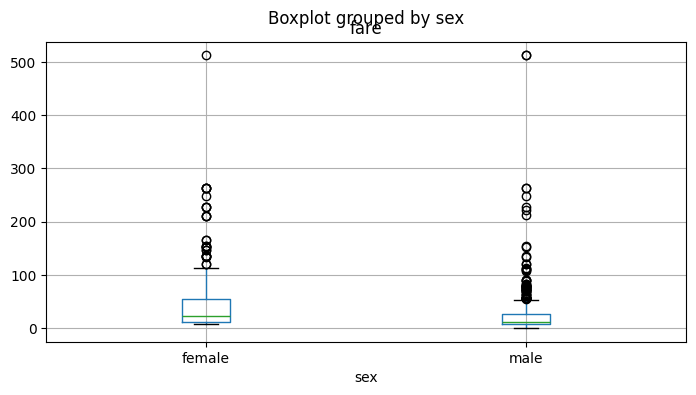

In [13]:
df.boxplot(column='fare', by='sex', figsize=(8, 4))
plt.show()

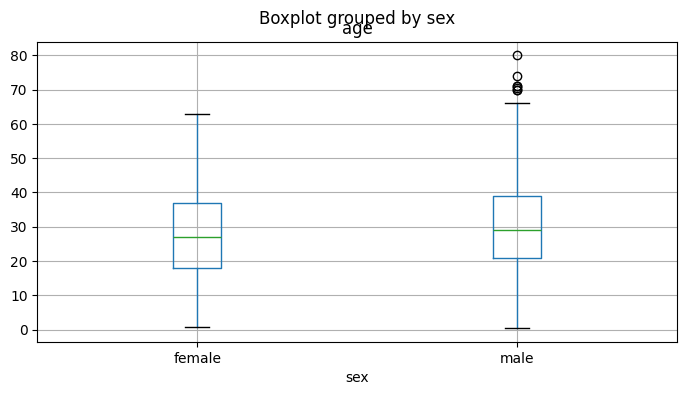

In [14]:
df.boxplot(column='age', by='sex', figsize=(8, 4))
plt.show()

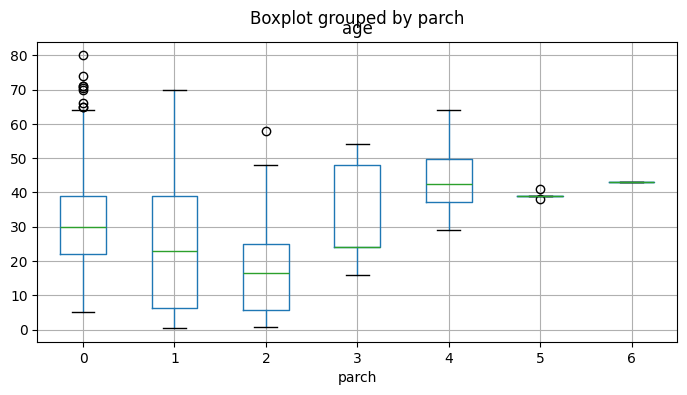

In [15]:
df.boxplot(column='age', by='parch', figsize=(8, 4))
plt.show()

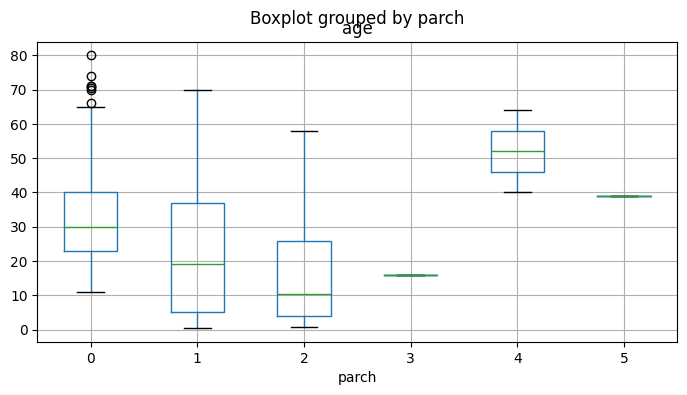

In [16]:
df[df['sex'] == 'male'].boxplot(column='age', by='parch', figsize=(8, 4))
plt.show()

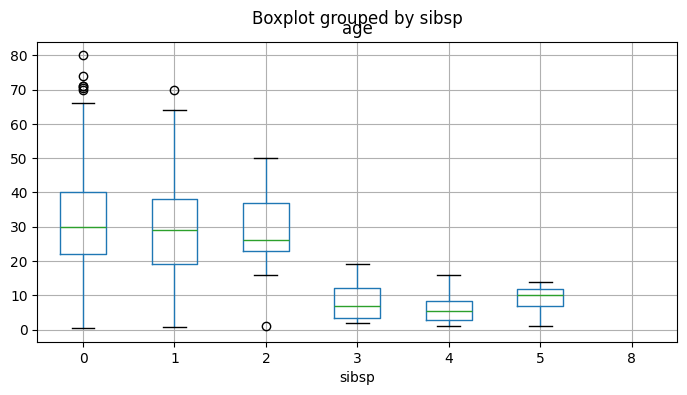

In [17]:
df[df['sex'] == 'male'].boxplot(column='age', by='sibsp', figsize=(8, 4))
plt.show()

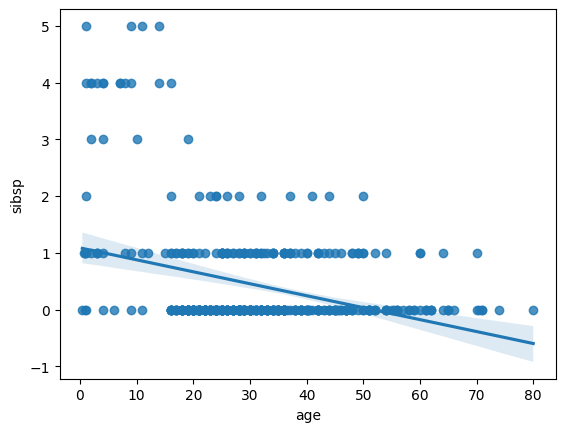

In [18]:
import seaborn as sns

sns.regplot(data=df[df['sex'] == 'male'], x='age', y='sibsp')
plt.show()

In [19]:
from scipy.stats import chi2_contingency

for col in ['pclass', 'sex', 'sibsp', 'parch', 'embarked']:
    ct = pd.crosstab(df['survived'], df[col])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.3f}, p={p:.4f}")

pclass: chi2=102.889, p=0.0000
sex: chi2=260.717, p=0.0000
sibsp: chi2=37.272, p=0.0000
parch: chi2=27.926, p=0.0001
embarked: chi2=26.489, p=0.0000


In [20]:
from scipy.stats import ttest_ind

for col in ['age', 'fare']:
    group0 = df[df['survived'] == 0][col].dropna()
    group1 = df[df['survived'] == 1][col].dropna()
    t, p = ttest_ind(group0, group1)
    print(f"{col}: t={t:.3f}, p={p:.4f}")

age: t=2.067, p=0.0391
fare: t=-7.939, p=0.0000


In [21]:
pd.crosstab(df['survived'], df['parch'], normalize='index').round(3)

parch,0,1,2,3,4,5,6
survived,,,,,,,
0,0.811,0.097,0.073,0.004,0.007,0.007,0.002
1,0.681,0.190,0.117,0.009,0.000,0.003,0.000


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

df_model = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

# Preenche missing de age com a mediana
df_model['age'] = df_model['age'].fillna(df_model['age'].median())

# Preenche missing de embarked com a moda
df_model['embarked'] = df_model['embarked'].fillna(df_model['embarked'].mode()[0])

# Encoding
df_model['sex'] = LabelEncoder().fit_transform(df_model['sex'])
df_model = pd.get_dummies(df_model, columns=['embarked'], drop_first=True)

X = df_model.drop('survived', axis=1)
y = df_model['survived']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Coeficientes
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(coef)

sex          -2.618603
pclass       -1.066800
embarked_S   -0.383816
sibsp        -0.314918
parch        -0.079689
age          -0.038249
embarked_Q   -0.030331
fare          0.002188
dtype: float64


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

AUC-ROC: 0.882


In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier()
}

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    print(f"{name}: F1={f1:.3f}, AUC-ROC={auc:.3f}")

Logistic Regression: F1=0.809, AUC-ROC=0.882
Random Forest: F1=0.809, AUC-ROC=0.888
Gradient Boosting: F1=0.801, AUC-ROC=0.881
SVM: F1=0.599, AUC-ROC=0.807
KNN: F1=0.701, AUC-ROC=0.772
